In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


sns.set_theme(style="ticks")
sns.set_context("paper")

PATH_SIMDATA = "../sim_results/"

# Simulation Results
## Lasso

In [2]:
sim_lassoreult_df = pd.read_csv(PATH_SIMDATA + "dmldid_rcs_with_simdata_lasso.csv")[
    [
        "abadie_semidid",
        "few_fixed_bar",
        "modified_dmldid_without_separate",
        "modified_dmldid_with_separate",
    ]
]
sim_lassoreult_df

,abadie_semidid,few_fixed_bar,modified_dmldid_without_separate,modified_dmldid_with_separate
0,4.327607,6.844921,1.986109,4.220909
1,5.827066,7.226370,6.857190,2.330296
2,1.338907,1.667278,6.829171,2.458440
3,9.166702,9.003266,3.541196,4.541945
4,4.148011,5.124704,6.787059,2.632568
...,...,...,...,...
995,4.709480,5.195413,6.478031,3.263947
996,8.487737,12.145365,9.500024,3.281846
997,5.505878,6.784661,8.177554,3.505544
998,5.143983,7.091428,8.433270,3.533206


In [3]:
_label = [
    f"(a) Abadie (2005)'s Approach \n ( MAE from true ATT = {np.abs(3-sim_lassoreult_df.abadie_semidid.mean()):.3f} )",
    f"(b) Chang (2020)'s Approach \n ( MAE from true ATT = {np.abs(3-sim_lassoreult_df.few_fixed_bar.mean()):.3f} )",
    "(c) Modified DMLDiD with Non-Separate $\ell_2^{mod}$ \n"
    + f"( MAE from true ATT = {np.abs(3-sim_lassoreult_df.modified_dmldid_without_separate.mean()):.3f} )",
    "(d) Modified DMLDiD with Separate $\ell_2^{mod}$ \n"
    + f"( MAE from true ATT = {np.abs(3-sim_lassoreult_df.modified_dmldid_with_separate.mean()):.3f} )",
]

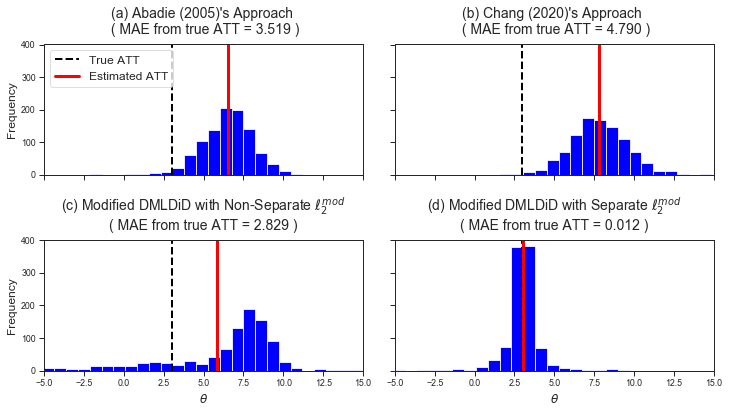

In [4]:
fig, axs = plt.subplots(2, 2, sharex="col", sharey=True, figsize=(12, 6), gridspec_kw=dict(hspace=0.5, wspace=0.1))
axs = axs.ravel()
# ビンの境界を計算
global_min = sim_lassoreult_df.min().min()
global_max = sim_lassoreult_df.max().max()
bins = np.linspace(global_min, global_max, 100)

for i, _col in enumerate(sim_lassoreult_df.columns):
    sim_lassoreult_df[_col].hist(bins=bins, ax=axs[i], color="blue", grid=False)
    # sns.kdeplot(sim_lassoreult_df[_col], shade=True, color="red", ax=axs[i])
    axs[i].set_xlim(-5, 15)
    axs[i].set_title(_label[i], fontsize=14, pad=10)
    axs[i].axvline(x=3, alpha=1, color="black", lw=2, ls="--")
    axs[i].axvline(x=sim_lassoreult_df[_col].mean(), color="red", alpha=1, lw=3)
    axs[i].set_xlabel("")


for j in range(len(sim_lassoreult_df.columns), len(axs)):
    fig.delaxes(axs[j])
axs[0].legend(["True ATT", "Estimated ATT"], loc="upper left", fontsize=12)
axs[2].set_xlabel(r"$\theta$", fontsize=12)
axs[3].set_xlabel(r"$\theta$", fontsize=12)
axs[0].set_ylabel("Frequency", fontsize=12)
axs[2].set_ylabel("Frequency", fontsize=12)

fig.savefig("../fig/simdata_results_lasso.png", dpi=600, bbox_inches="tight")

plt.show()

In [5]:
print(sim_lassoreult_df.describe().loc[["mean", "std"]].round(3).to_latex())

\begin{tabular}{lrrrr}
\toprule
{} &  abadie\_semidid &  few\_fixed\_bar &  modified\_dmldid\_without\_separate &  modified\_dmldid\_with\_separate \\
\midrule
mean &           6.519 &          7.790 &                             5.829 &                          3.012 \\
std  &           1.562 &          1.719 &                             5.476 &                          1.160 \\
\bottomrule
\end{tabular}



## lightgbm

In [6]:
sim_lgbtreult_df = pd.read_csv(PATH_SIMDATA + "dimldid_rcs_with_simdata_lgbm.csv")
sim_lgbtreult_df

,abadie_semidid,original_dmldid,modified_dmldid,modified_dmldid_with_separate
0,5.421862,0.969098,3.010074,3.095854
1,6.020707,-0.035676,2.730593,2.952687
2,5.531775,0.301822,2.807935,2.933310
3,5.874473,1.974111,3.141967,3.140530
4,5.623065,0.481676,3.031651,3.042614
...,...,...,...,...
995,6.057128,1.960723,2.835378,2.938528
996,5.654658,-1.534293,2.633778,2.848611
997,6.299234,-0.399050,2.694219,2.815056
998,5.039223,0.213391,2.419215,2.606721


In [7]:
_label = [
    f"(a) Abadie (2005)'s Approach \n ( MAE from true ATT = {np.abs(3-sim_lgbtreult_df.abadie_semidid.mean()):.3f} )",
    f"(b) Chang (2020)'s Approach \n ( MAE from true ATT = {np.abs(3-sim_lgbtreult_df.original_dmldid.mean()):.3f} )",
    "(c) Modified DMLDiD with Non-Separate $\ell_2^{mod}$ \n"
    + f"( MAE from true ATT = {np.abs(3-sim_lgbtreult_df.modified_dmldid.mean()):.3f} )",
    "(d) Modified DMLDiD with Separate $\ell_2^{mod}$ \n"
    + f"( MAE from true ATT = {np.abs(3-sim_lgbtreult_df.modified_dmldid_with_separate.mean()):.3f} )",
]

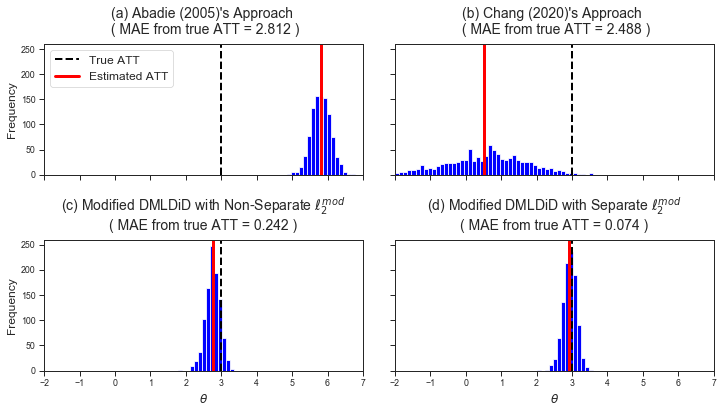

In [8]:
fig, axs = plt.subplots(2, 2, sharex="col", sharey=True, figsize=(12, 6), gridspec_kw=dict(hspace=0.5, wspace=0.1))
axs = axs.ravel()

# ビンの境界を計算
global_min = sim_lgbtreult_df.min().min()
global_max = sim_lgbtreult_df.max().max()
bins = np.linspace(global_min, global_max, 100) 

for i, _col in enumerate(sim_lgbtreult_df.columns):
    sim_lgbtreult_df[_col].hist(ax=axs[i], bins=bins, color="blue", grid=False)
    #sns.kdeplot(sim_lgbtreult_df[_col], shade=True, color="red", ax=axs[i])
    axs[i].set_xlim(-2, 7)
    axs[i].set_title(_label[i], fontsize=14, pad=10)
    axs[i].axvline(x=3, alpha=1, color="black", lw=2, ls="--")
    axs[i].axvline(x=sim_lgbtreult_df[_col].mean(),  color="red", alpha=1, lw=3)
    axs[i].set_xlabel("")


for j in range(len(sim_lgbtreult_df.columns), len(axs)):
    fig.delaxes(axs[j])
axs[0].legend(["True ATT", "Estimated ATT"], loc="upper left", fontsize=12)
axs[2].set_xlabel(r"$\theta$", fontsize=12)
axs[3].set_xlabel(r"$\theta$", fontsize=12)
axs[0].set_ylabel("Frequency", fontsize=12)
axs[2].set_ylabel("Frequency", fontsize=12)

fig.savefig("../fig/simdata_results_lgbm.png", dpi=600, bbox_inches="tight")

plt.show()

In [9]:
print(sim_lgbtreult_df.describe().loc[["mean", "std"]].round(3).to_latex())

\begin{tabular}{lrrrr}
\toprule
{} &  abadie\_semidid &  original\_dmldid &  modified\_dmldid &  modified\_dmldid\_with\_separate \\
\midrule
mean &           5.812 &            0.512 &            2.758 &                          2.926 \\
std  &           0.271 &            1.175 &            0.201 &                          0.191 \\
\bottomrule
\end{tabular}



# RO data
## Chang(2020)'s Data


In [10]:
ro_chang_df = pd.read_csv(PATH_SIMDATA + "ro_simdata_chang.csv")
ro_chang_df

,naive_did,abadie_lasso_result,dmldid_lasso_result
0,2.994106,3.667854,2.980136
1,3.022615,3.075453,3.022785
2,3.002056,3.568907,2.972580
3,2.966953,3.504126,2.845537
4,3.023824,3.571317,3.071792
...,...,...,...
995,3.010496,3.427195,3.036421
996,2.950506,3.111088,2.838579
997,2.993036,3.485948,3.014669
998,2.988184,3.087069,3.332155


In [11]:
_label = [
    f"(a) Naive DiD \n ( MAE from true ATT = {np.abs(3-ro_chang_df.naive_did.mean()):.3f} )",
    f"(b) Abadie (2005)'s Approach \n ( MAE from true ATT = {np.abs(3-ro_chang_df.abadie_lasso_result.mean()):.3f} )",
    f"(c) Chang (2020)'s Approach \n ( MAE from true ATT = {np.abs(3-ro_chang_df.dmldid_lasso_result.mean()):.3f} )",
]

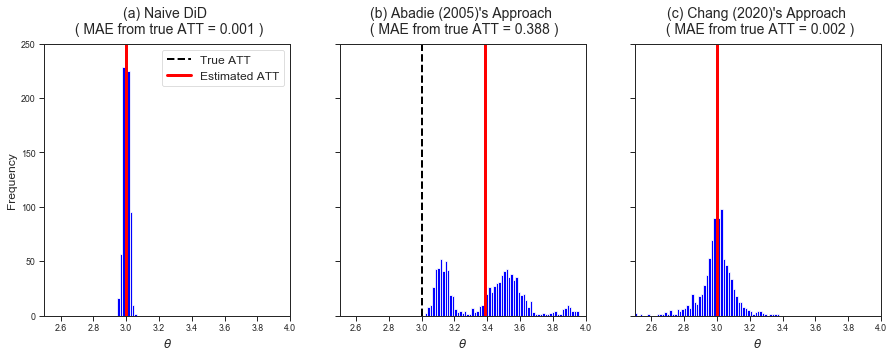

In [12]:
fig, axs = plt.subplots(1, 3, sharex="col", sharey=True, figsize=(15, 5))
axs = axs.ravel()
global_min = ro_chang_df.min().min()
global_max = ro_chang_df.max().max()
bins = np.linspace(global_min, global_max, 100) 
for i, _col in enumerate(ro_chang_df.columns):
    ro_chang_df[_col].hist(bins=bins, ax=axs[i], color="blue", grid=False)
    #sns.kdeplot(ro_chang_df[_col], shade=True, color="red", ax=axs[i])
    axs[i].set_xlim(2.5, 4)
    axs[i].set_ylim(0, 250)
    axs[i].set_title(_label[i], fontsize=14, pad=10)
    axs[i].axvline(x=3, alpha=1, color="black", lw=2, ls="--")
    axs[i].axvline(x=ro_chang_df[_col].mean(),  color="red", alpha=1, lw=3)
    axs[i].set_xlabel(r"$\theta$", fontsize=12)



axs[0].legend(["True ATT", "Estimated ATT"], loc="upper right", fontsize=12)

axs[0].set_ylabel("Frequency", fontsize=12)


fig.savefig("../fig/appendix_ro_lasso_original_sim.png", dpi=600, bbox_inches="tight")

plt.show()

In [13]:
print(ro_chang_df.describe().loc[["mean", "std"]].round(3).to_latex())

\begin{tabular}{lrrr}
\toprule
{} &  naive\_did &  abadie\_lasso\_result &  dmldid\_lasso\_result \\
\midrule
mean &      2.999 &                3.388 &                2.998 \\
std  &      0.017 &                0.228 &                0.099 \\
\bottomrule
\end{tabular}



## new sim data

In [14]:
ro_new_df = pd.read_csv(PATH_SIMDATA + "ro_simdata_newdata_lasso.csv")
ro_new_df

,naive_did,abadie_lasso_result,dmldid_lasso_result
0,8.512346,3.861926,3.119853
1,9.398698,6.471206,1.861079
2,8.522122,5.794754,3.200066
3,8.752810,6.872401,2.869287
4,8.440206,6.086001,2.914869
...,...,...,...
995,6.862392,4.593168,2.261178
996,11.476340,4.387765,3.210553
997,9.788449,6.938346,3.094953
998,11.261711,6.176725,3.253294


In [15]:
_label = [
    f"(a) Naive DiD \n ( MAE from true ATT = {np.abs(3-ro_new_df.naive_did.mean()):.3f} )",
    f"(b) Abadie (2005)'s Approach \n ( MAE from true ATT = {np.abs(3-ro_new_df.abadie_lasso_result.mean()):.3f} )",
    f"(c) Chang (2020)'s Approach \n ( MAE from true ATT = {np.abs(3-ro_new_df.dmldid_lasso_result.mean()):.3f} )",
]

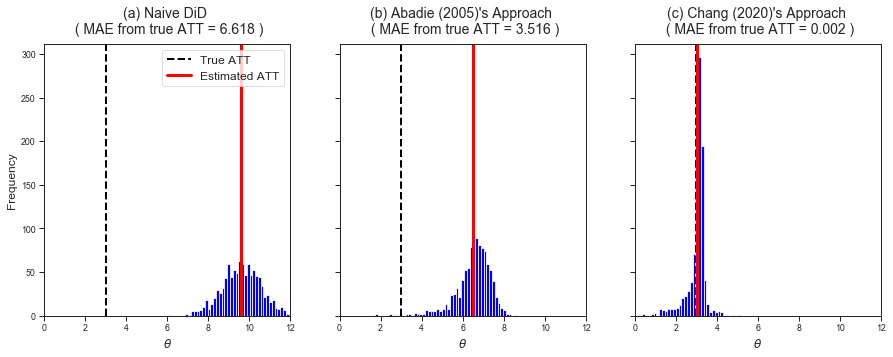

In [16]:
fig, axs = plt.subplots(1, 3, sharex="col", sharey=True, figsize=(15, 5))
axs = axs.ravel()
global_min = ro_new_df.min().min()
global_max = ro_new_df.max().max()
bins = np.linspace(global_min, global_max, 100) 
for i, _col in enumerate(ro_new_df.columns):
    ro_new_df[_col].hist(bins=bins, ax=axs[i], color="blue", grid=False)
    axs[i].set_xlim(0, 12)
    #axs[i].set_ylim(0, 300)
    axs[i].set_title(_label[i], fontsize=14, pad=10)
    axs[i].axvline(x=3, alpha=1, color="black", lw=2, ls="--")
    axs[i].axvline(x=ro_new_df[_col].mean(),  color="red", alpha=1, lw=3)
    axs[i].set_xlabel(r"$\theta$", fontsize=12)



axs[0].legend(["True ATT", "Estimated ATT"], loc="upper right", fontsize=12)

axs[0].set_ylabel("Frequency", fontsize=12)


fig.savefig("../fig/appendix_ro_lasso.png", dpi=600, bbox_inches="tight")

plt.show()

In [17]:
print(ro_new_df.describe().loc[["mean", "std"]].round(3).to_latex())

\begin{tabular}{lrrr}
\toprule
{} &  naive\_did &  abadie\_lasso\_result &  dmldid\_lasso\_result \\
\midrule
mean &      9.618 &                6.516 &                3.002 \\
std  &      0.968 &                0.871 &                0.483 \\
\bottomrule
\end{tabular}



In [18]:
print("Done")

Done
